In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_stores=pd.read_csv("dim_stores.csv")
df_stores.head()

,store_id,city
0,STTRV-0,Trivandrum
1,STMDU-3,Madurai
2,STHYD-6,Hyderabad
3,STVSK-1,Visakhapatnam
4,STCBE-3,Coimbatore


1. Visualize the number of stores in each city. Identify the city with the most stores and explain the distribution of stores across other cities. How does the number of stores in Bengaluru compare with those in Hyderabad and Chennai? (Hint: Use a bar chart to visualize the number of stores by city)


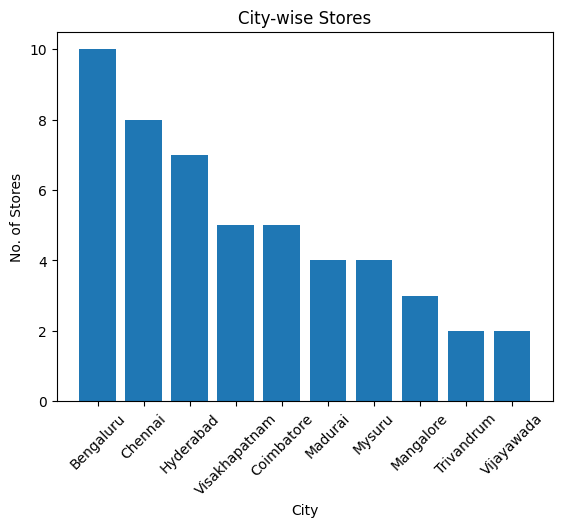

In [3]:
store_count = df_stores['city'].value_counts()

plt.bar(store_count.index, store_count.values)

plt.xlabel('City')
plt.ylabel('No. of Stores')
plt.title('City-wise Stores')

plt.xticks(rotation=45)
plt.show()

2. Analyze the total quantity sold after promotion for the Sankranti campaign across different product categories. What percentage does each category contribute to the overall sales, and what insights can be drawn from these contributions? (Hint: Use a pie chart to visualize percentage contribution of each category to the overall sales)

In [4]:
df_products = pd.read_csv("dim_products.csv")
df_events = pd.read_csv("fact_events.csv")
df_campaigns = pd.read_csv("dim_campaigns.csv")

df1=df_products.merge(df_events,on='product_code')
df_merged = df1.merge(df_campaigns,on='campaign_id')
df_merged.head()

,product_code,product_name,category,event_id,store_id,campaign_id,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),campaign_name,start_date,end_date
0,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,31c430,STHYD-1,CAMP_SAN_01,172,312.0,33% OFF,115,393,Sankranti,10-01-2024,16-01-2024
1,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,029ff8,STMLR-0,CAMP_SAN_01,172,169.0,33% OFF,115,236,Sankranti,10-01-2024,16-01-2024
2,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,fad26a,STCHE-3,CAMP_DIW_01,172,369.0,33% OFF,115,546,Diwali,12-11-2023,18-11-2023
3,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,166989,STCBE-1,CAMP_SAN_01,172,169.0,33% OFF,115,206,Sankranti,10-01-2024,16-01-2024
4,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,3cb389,STCHE-6,CAMP_DIW_01,172,309.0,33% OFF,115,460,Diwali,12-11-2023,18-11-2023


In [5]:
df_sankranti=df_merged[df_merged['campaign_name']=='Sankranti']
df_sankranti.head()

,product_code,product_name,category,event_id,store_id,campaign_id,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo),campaign_name,start_date,end_date
0,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,31c430,STHYD-1,CAMP_SAN_01,172,312.0,33% OFF,115,393,Sankranti,10-01-2024,16-01-2024
1,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,029ff8,STMLR-0,CAMP_SAN_01,172,169.0,33% OFF,115,236,Sankranti,10-01-2024,16-01-2024
3,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,166989,STCBE-1,CAMP_SAN_01,172,169.0,33% OFF,115,206,Sankranti,10-01-2024,16-01-2024
5,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,21a8a0,STBLR-4,CAMP_SAN_01,172,286.0,33% OFF,115,394,Sankranti,10-01-2024,16-01-2024
8,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples,667c78,STVSK-4,CAMP_SAN_01,172,223.0,33% OFF,115,301,Sankranti,10-01-2024,16-01-2024


                   Total Quantity Sold  Percentage Contribution
category                                                       
Combo1                           12411                 4.923652
Grocery & Staples               177724                70.506092
Home Appliances                  35610                14.127084
Home Care                        16894                 6.702133
Personal Care                     9430                 3.741039


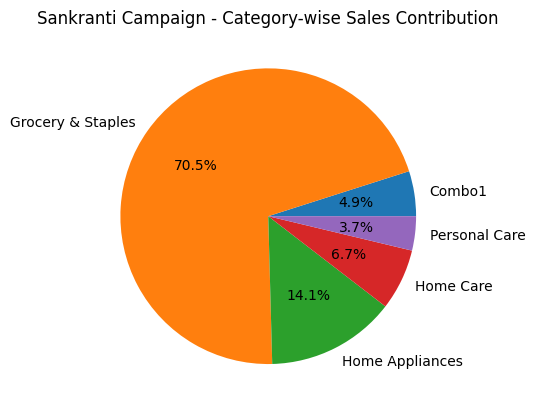

In [6]:
# Total quantity sold after promotion by category
category_sales = df_sankranti.groupby('category')['quantity_sold(after_promo)'].sum()

# Percentage contribution
percentage = (category_sales / category_sales.sum()) * 100

# Create result table
result = pd.DataFrame({
    'Total Quantity Sold': category_sales,
    'Percentage Contribution': percentage
})

print(result)

# Pie chart
plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title('Sankranti Campaign - Category-wise Sales Contribution')
plt.show()

3. Examine the correlation between base price (after the promotion) and sales quantities (after the promotion). What insights can be drawn regarding the relationship between base price and sales quantities after the promotion? (Hint: Use heatmap to get the correlation)


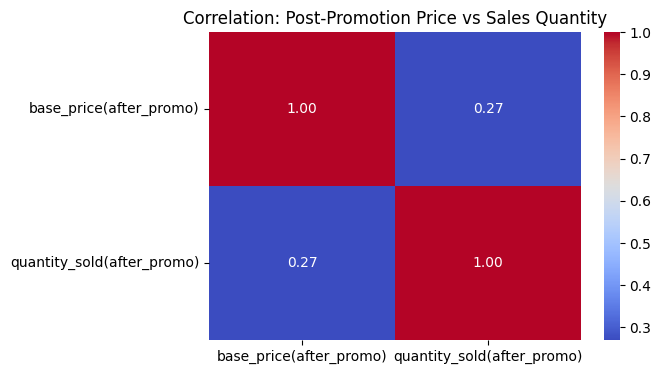

In [7]:
corr = df_events[['base_price(after_promo)', 'quantity_sold(after_promo)']].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation: Post-Promotion Price vs Sales Quantity')
plt.show()

4. Analyze the distribution of quantity sold before the promotion for each product category (Grocery & Staples, Home Care, Personal Care, Home Appliances,etc.). What patterns or trends do you observe across these categories, and how could these insights inform future promotional strategies?(Hint: Use individual histograms to visualize the distribution)


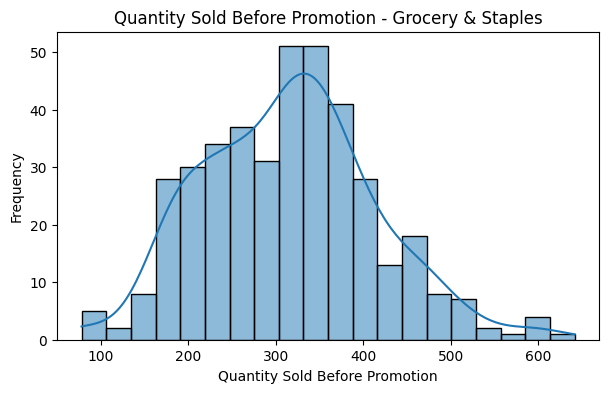

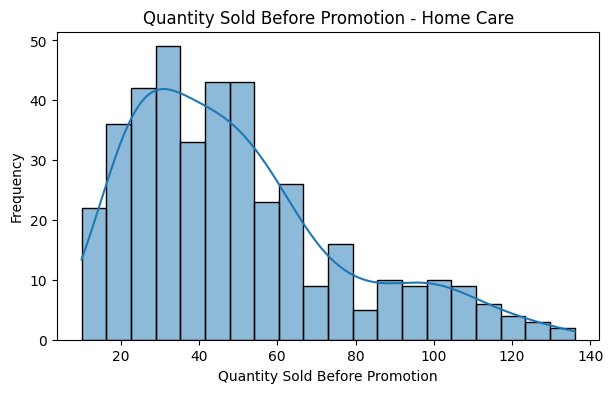

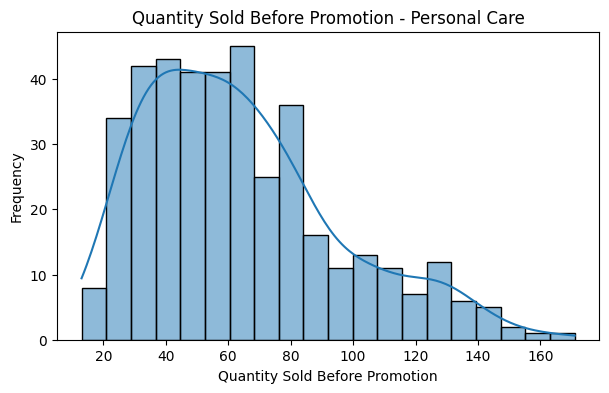

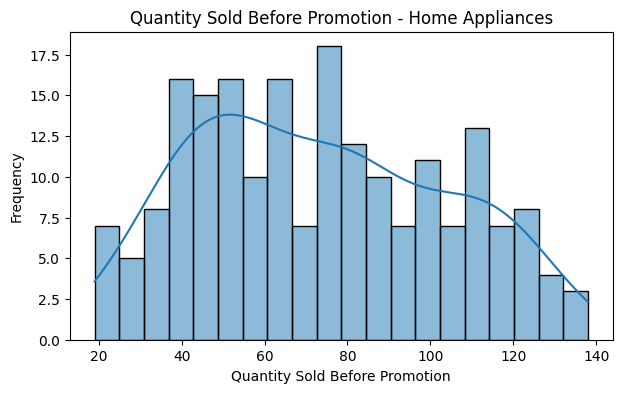

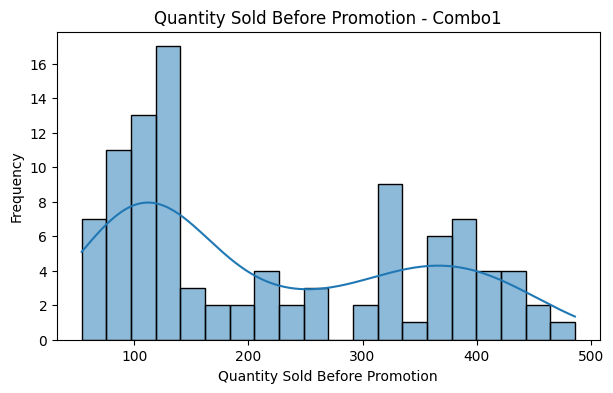

In [8]:
categories = df1['category'].unique()

for category in categories:
    data = df1[df1['category'] == category]['quantity_sold(before_promo)'].dropna()

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data,
        bins=20,
        kde=True
    )

    plt.title(f'Quantity Sold Before Promotion - {category}')
    plt.xlabel('Quantity Sold Before Promotion')
    plt.ylabel('Frequency')

    plt.show()

5. Analyze the incremental sold units percentage (ISU%) across various cities. Identify the city with the highest ISU% after the promotion and the city with the smallest change. What trends can be observed about the effectiveness of promotions in driving sales across these cities? (Hint: Use a line chart to visualize the ISU% comparison across cities)

In [9]:
df2=df_stores.merge(df_events, on ='store_id')
df2.head()

,store_id,city,event_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo)
0,STTRV-0,Trivandrum,4236be,CAMP_SAN_01,P14,1020,70.0,BOGOF,510,280
1,STTRV-0,Trivandrum,e97ac0,CAMP_SAN_01,P12,62,22.0,50% OFF,31,30
2,STTRV-0,Trivandrum,565a38,CAMP_SAN_01,P07,300,30.0,BOGOF,150,117
3,STTRV-0,Trivandrum,ea916f,CAMP_SAN_01,P10,50,18.0,25% OFF,37,16
4,STTRV-0,Trivandrum,30c488,CAMP_SAN_01,P01,172,132.0,33% OFF,115,187


In [10]:
city_sales = df2.groupby('city').agg({
    'quantity_sold(before_promo)': 'sum',
    'quantity_sold(after_promo)': 'sum'
})

city_sales

,quantity_sold(before_promo),quantity_sold(after_promo)
city,,
Bengaluru,48972.0,105141
Chennai,39183.0,83273
Coimbatore,18200.0,38900
Hyderabad,34335.0,69399
Madurai,14086.0,31169
Mangalore,7454.0,14929
Mysuru,18202.0,37470
Trivandrum,4884.0,10170
Vijayawada,5297.0,11106


In [11]:
city_sales['ISU%'] = ((city_sales['quantity_sold(after_promo)'] -city_sales['quantity_sold(before_promo)'])
    / city_sales['quantity_sold(before_promo)']
) * 100

In [12]:
city_sales

,quantity_sold(before_promo),quantity_sold(after_promo),ISU%
city,,,
Bengaluru,48972.0,105141,114.696153
Chennai,39183.0,83273,112.523288
Coimbatore,18200.0,38900,113.736264
Hyderabad,34335.0,69399,102.123198
Madurai,14086.0,31169,121.276445
Mangalore,7454.0,14929,100.281728
Mysuru,18202.0,37470,105.856499
Trivandrum,4884.0,10170,108.230958
Vijayawada,5297.0,11106,109.665849


In [13]:
highest_city = city_sales['ISU%'].idxmax()
highest_isu = city_sales['ISU%'].max()

smallest_city = city_sales['ISU%'].idxmin()
smallest_isu = city_sales['ISU%'].min()

print("Highest ISU%:", highest_city, highest_isu)
print("Smallest ISU%:", smallest_city, smallest_isu)

Highest ISU%: Madurai 121.27644469686214
Smallest ISU%: Visakhapatnam 99.07260667957974


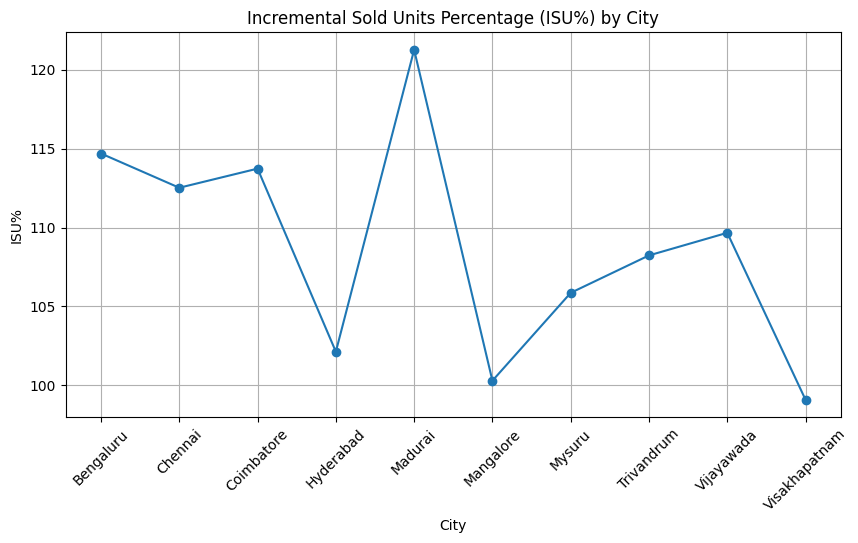

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    city_sales.index,
    city_sales['ISU%'],
    marker='o'
)

plt.xlabel('City')
plt.ylabel('ISU%')
plt.title('Incremental Sold Units Percentage (ISU%) by City')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

6. Analyze the relationship between incremental revenue and incremental sold units for different promotion types in Hyderabad. Which promotion type led to the highest incremental sold units, and which one generated the highest incremental revenue? What insights can you draw from the balance between the two metrics for this city? (Hint: Use a scatter plot to analyze the relationship)


In [15]:
df_hyd = df2[df2['city'] == 'Hyderabad'].copy()

In [16]:
df_hyd['incremental_units'] = (
    df_hyd['quantity_sold(after_promo)']
    - df_hyd['quantity_sold(before_promo)']
)

In [17]:
df_hyd['revenue_before'] = (
    df_hyd['base_price(before_promo)']
    * df_hyd['quantity_sold(before_promo)']
)

df_hyd['revenue_after'] = (
    df_hyd['base_price(after_promo)']
    * df_hyd['quantity_sold(after_promo)']
)

In [18]:
df_hyd['incremental_revenue'] = (
    df_hyd['revenue_after']
    - df_hyd['revenue_before']
)

In [19]:
promo_analysis = df_hyd.groupby('promo_type').agg({
    'incremental_units': 'sum',
    'incremental_revenue': 'sum'
})

print(promo_analysis)

              incremental_units  incremental_revenue
promo_type                                          
25% OFF                  -940.0            -537943.0
33% OFF                  4700.0            -179239.0
50% OFF                  1291.0            -115322.0
500 Cashback             5845.0           12866500.0
BOGOF                   24168.0            3182420.0


In [20]:
highest_units = promo_analysis['incremental_units'].idxmax()
highest_revenue = promo_analysis['incremental_revenue'].idxmax()

print("Highest Incremental Units:", highest_units)
print("Highest Incremental Revenue:", highest_revenue)

Highest Incremental Units: BOGOF
Highest Incremental Revenue: 500 Cashback


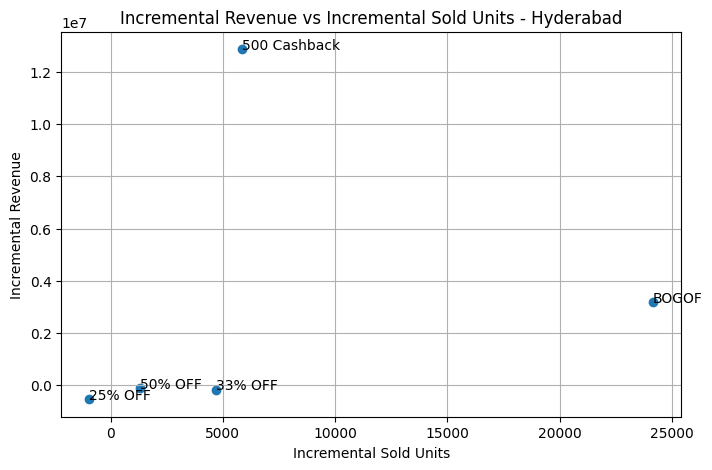

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    promo_analysis['incremental_units'],
    promo_analysis['incremental_revenue']
)

for promo, row in promo_analysis.iterrows():
    plt.annotate(
        promo,
        (row['incremental_units'], row['incremental_revenue'])
    )

plt.xlabel('Incremental Sold Units')
plt.ylabel('Incremental Revenue')
plt.title('Incremental Revenue vs Incremental Sold Units - Hyderabad')

plt.grid(True)
plt.show()

7. Analyze the revenue before and after promotions across different product categories in Bengaluru. What trends can be identified in the performance of each category, and how did promotions impact overall revenue in the city? (Hint: Use a vertical bar chart to compare the revenue before and after promotions)

In [22]:
df3=df2.merge(df_products, on='product_code')

In [23]:
df_bengaluru = df3[df3['city'] == 'Bengaluru'].copy()

In [24]:
df_bengaluru['revenue_before'] = (
    df_bengaluru['base_price(before_promo)']
    * df_bengaluru['quantity_sold(before_promo)']
)

df_bengaluru['revenue_after'] = (
    df_bengaluru['base_price(after_promo)']
    * df_bengaluru['quantity_sold(after_promo)']
)

In [25]:
category_revenue = df_bengaluru.groupby('category').agg({
    'revenue_before': 'sum',
    'revenue_after': 'sum'
})

print(category_revenue)

                   revenue_before  revenue_after
category                                        
Combo1                 15777000.0       38125000
Grocery & Staples      12262460.0       13861259
Home Appliances         2188810.0        4122680
Home Care               2104460.0        3180020
Personal Care            576321.0         389629


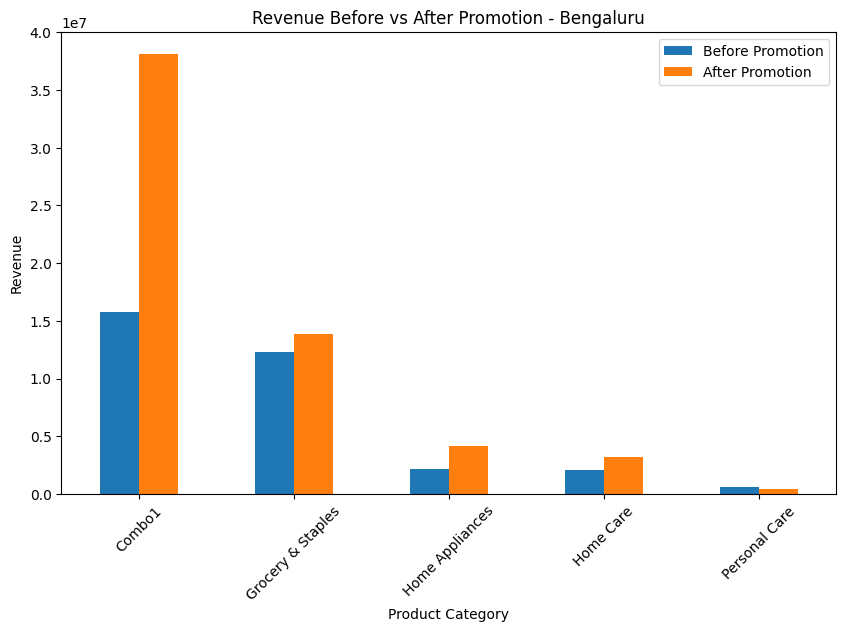

In [26]:
category_revenue.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.title('Revenue Before vs After Promotion - Bengaluru')

plt.xticks(rotation=45)
plt.legend(['Before Promotion', 'After Promotion'])

plt.show()

In [27]:
category_revenue['revenue_change'] = (
    category_revenue['revenue_after']
    - category_revenue['revenue_before']
)

category_revenue['revenue_change_%'] = (
    category_revenue['revenue_change']
    / category_revenue['revenue_before']
) * 100

print(category_revenue)

                   revenue_before  revenue_after  revenue_change  \
category                                                           
Combo1                 15777000.0       38125000      22348000.0   
Grocery & Staples      12262460.0       13861259       1598799.0   
Home Appliances         2188810.0        4122680       1933870.0   
Home Care               2104460.0        3180020       1075560.0   
Personal Care            576321.0         389629       -186692.0   

                   revenue_change_%  
category                             
Combo1                   141.649236  
Grocery & Staples         13.038159  
Home Appliances           88.352575  
Home Care                 51.108598  
Personal Care            -32.393753  
